# 🎓 EduPro – Student Segmentation & Personalized Course Recommendation System
### Data Analysis Notebook | Aspiring Data Analyst Report

---

**Objective:** Segment EduPro learners into meaningful behavioral clusters and build a personalized course recommendation engine using unsupervised machine learning.

**Dataset:** EduPro_Online_Platform.xlsx  
**Sheets Used:** Users · Courses · Transactions

---


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
from google.colab import files

XLSX_PATH = '/content/EduPro Online Platform.xlsx' # Corrected filename with spaces

if os.path.exists(XLSX_PATH):
    print(f'✅ File already exists: {XLSX_PATH}')
else:
    print(f'❌ Error: File not found at {XLSX_PATH}. Please ensure the file is uploaded to the Colab environment.')
    # Removed files.upload() to prevent manual selection as requested.

✅ File already exists: /content/EduPro Online Platform.xlsx


## 📦 Section 1 – Environment Setup & Library Imports

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import cdist
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# ── Global style ─────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': '#0f0f1a',
    'axes.facecolor':   '#1a1a2e',
    'axes.edgecolor':   '#444466',
    'axes.labelcolor':  '#e0e0ff',
    'xtick.color':      '#c0c0e0',
    'ytick.color':      '#c0c0e0',
    'text.color':       '#e0e0ff',
    'grid.color':       '#2a2a4a',
    'grid.linestyle':   '--',
    'grid.alpha':       0.5,
    'font.family':      'DejaVu Sans',
})

PALETTE = ['#6c63ff','#ff6584','#43e97b','#f7971e','#0ea5e9',
           '#a855f7','#ec4899','#14b8a6','#fb923c','#84cc16']

print("✅ All libraries imported successfully!")


✅ All libraries imported successfully!


## 📂 Section 2 – Data Loading & Preliminary Inspection

In [ ]:
FILE_PATH = '/content/EduPro Online Platform.xlsx'

users_df  = pd.read_excel(FILE_PATH, sheet_name='Users')
courses_df = pd.read_excel(FILE_PATH, sheet_name='Courses')
trans_df  = pd.read_excel(FILE_PATH, sheet_name='Transactions')

print("=" * 60)
print("DATASET OVERVIEW")
print("=" * 60)
print(f"  Users       : {users_df.shape[0]:,} rows × {users_df.shape[1]} cols")
print(f"  Courses     : {courses_df.shape[0]:,} rows × {courses_df.shape[1]} cols")
print(f"  Transactions: {trans_df.shape[0]:,} rows × {trans_df.shape[1]} cols")

print("\n── Users Columns ──")
print(users_df.dtypes)
print("\n── Courses Columns ──")
print(courses_df.dtypes)
print("\n── Transactions Columns ──")
print(trans_df.dtypes)

DATASET OVERVIEW
  Users       : 3,000 rows × 5 cols
  Courses     : 60 rows × 8 cols
  Transactions: 10,000 rows × 7 cols

── Users Columns ──
UserID      object
UserName    object
Age          int64
Gender      object
Email       object
dtype: object

── Courses Columns ──
CourseID           object
CourseName         object
CourseCategory     object
CourseType         object
CourseLevel        object
CoursePrice       float64
CourseDuration    float64
CourseRating      float64
dtype: object

── Transactions Columns ──
TransactionID              object
UserID                     object
CourseID                   object
TransactionDate    datetime64[ns]
Amount                    float64
PaymentMethod              object
TeacherID                  object
dtype: object


In [ ]:
print("── Users (first 5) ──")
display(users_df.head())
print("\n── Courses (first 5) ──")
display(courses_df.head())
print("\n── Transactions (first 5) ──")
display(trans_df.head())

── Users (first 5) ──


,UserID,UserName,Age,Gender,Email
0,U00001,wilsonjordan,15,Male,patricia27@hotmail.com
1,U00002,angela22,29,Female,hallrandy@hotmail.com
2,U00003,morrisonamanda,33,Female,ganderson@yahoo.com
3,U00004,fthornton,23,Female,christensencatherine@outlook.com
4,U00005,fostergeoffrey,21,Male,karenfuentes@yahoo.com



── Courses (first 5) ──


,CourseID,CourseName,CourseCategory,CourseType,CourseLevel,CoursePrice,CourseDuration,CourseRating
0,CR00001,Python Basics,Programming,Paid,Beginner,472.28,11.00,4.74
1,CR00002,Java Programming,Programming,Free,Intermediate,0.00,37.70,2.43
2,CR00003,C++ for Beginners,Programming,Free,Beginner,0.00,19.53,3.85
3,CR00004,Advanced Python,Programming,Free,Beginner,0.00,45.13,2.88
4,CR00005,Full Stack Development,Programming,Free,Beginner,0.00,28.68,1.28



── Transactions (first 5) ──


,TransactionID,UserID,CourseID,TransactionDate,Amount,PaymentMethod,TeacherID
0,TT00001,U00003,CR00016,2025-10-25,0.0,PayPal,TC00040
1,TT00002,U00003,CR00037,2025-01-13,0.0,PayPal,TC00040
2,TT00003,U00003,CR00019,2025-03-28,0.0,Bank Transfer,TC00040
3,TT00004,U00004,CR00048,2025-06-02,0.0,Bank Transfer,TC00040
4,TT00005,U00004,CR00060,2025-08-10,0.0,PayPal,TC00042


In [ ]:
# Missing-value audit
print("Missing Values Summary")
print("=" * 40)
for name, df in [("Users", users_df), ("Courses", courses_df), ("Transactions", trans_df)]:
    mv = df.isnull().sum()
    mv = mv[mv > 0]
    if mv.empty:
        print(f"  {name}: ✅ No missing values")
    else:
        print(f"  {name}:\n{mv}")


Missing Values Summary
  Users: ✅ No missing values
  Courses: ✅ No missing values
  Transactions: ✅ No missing values


In [ ]:
# Basic descriptive statistics
print("── Transactions – Amount Statistics ──")
print(trans_df['Amount'].describe().round(2))

print("\n── Users – Age Distribution ──")
print(users_df['Age'].describe().round(2))

print("\n── Courses – CourseRating Distribution ──")
print(courses_df['CourseRating'].describe().round(2))


── Transactions – Amount Statistics ──
count    10000.00
mean        91.13
std        152.06
min          0.00
25%          0.00
50%          0.00
75%        119.04
max        490.90
Name: Amount, dtype: float64

── Users – Age Distribution ──
count    3000.00
mean       24.97
std         6.05
min        15.00
25%        20.00
50%        25.00
75%        30.00
max        35.00
Name: Age, dtype: float64

── Courses – CourseRating Distribution ──
count    60.00
mean      3.10
std       1.17
min       1.13
25%       2.11
50%       3.06
75%       4.10
max       4.94
Name: CourseRating, dtype: float64


## 🔍 Section 3 – Exploratory Data Analysis (EDA)

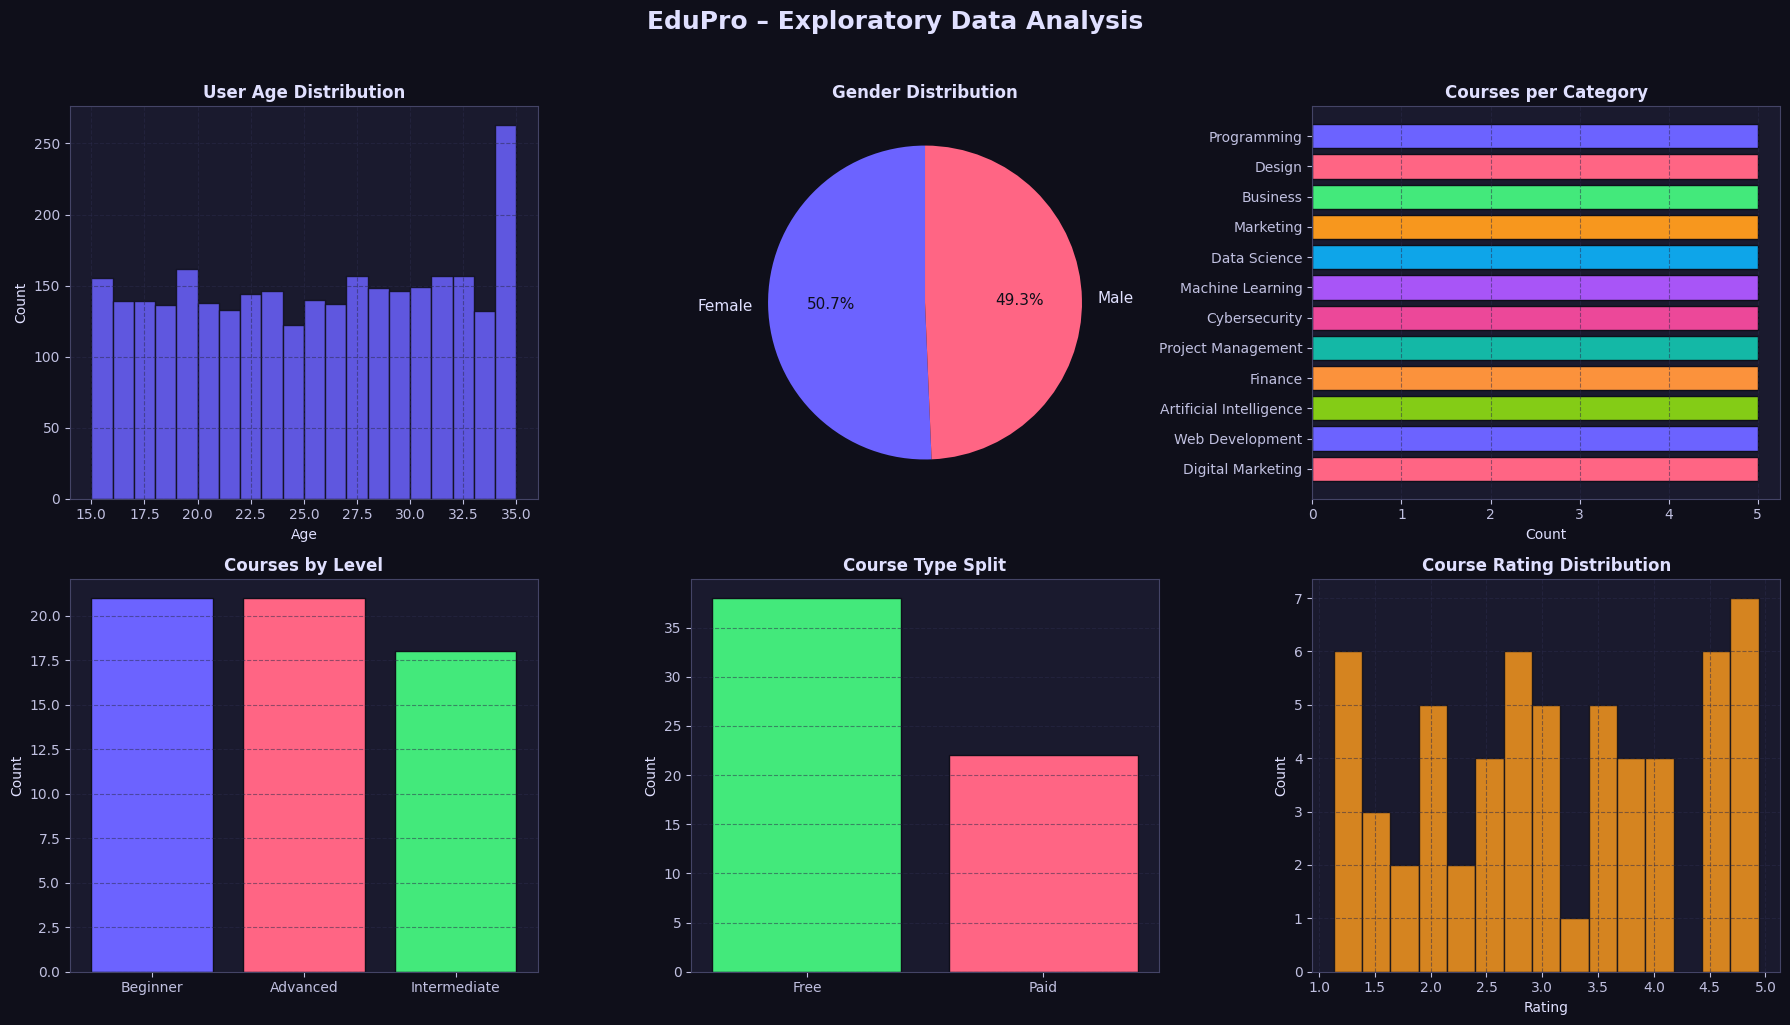

✅ EDA overview plot saved.


In [ ]:
import os

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("EduPro – Exploratory Data Analysis", fontsize=18, fontweight='bold',
             color='#e0e0ff', y=1.02)

# 1. Age distribution
ax = axes[0, 0]
ax.hist(users_df['Age'].dropna(), bins=20, color='#6c63ff', edgecolor='#0f0f1a', alpha=0.85)
ax.set_title("User Age Distribution", fontweight='bold')
ax.set_xlabel("Age"); ax.set_ylabel("Count")
ax.grid(True)

# 2. Gender split
ax = axes[0, 1]
gender_counts = users_df['Gender'].value_counts()
wedges, texts, autotexts = ax.pie(gender_counts.values,
    labels=gender_counts.index, autopct='%1.1f%%',
    colors=PALETTE[:len(gender_counts)],
    startangle=90, textprops={'color':'#e0e0ff', 'fontsize':11})
for at in autotexts: at.set_color('#0f0f1a')
ax.set_title("Gender Distribution", fontweight='bold')

# 3. Course category
ax = axes[0, 2]
cat_counts = courses_df['CourseCategory'].value_counts()
ax.barh(cat_counts.index, cat_counts.values,
        color=PALETTE[:len(cat_counts)], edgecolor='#0f0f1a')
ax.set_title("Courses per Category", fontweight='bold')
ax.set_xlabel("Count"); ax.invert_yaxis()
ax.grid(True, axis='x')

# 4. Course level
ax = axes[1, 0]
lv_counts = courses_df['CourseLevel'].value_counts()
ax.bar(lv_counts.index, lv_counts.values,
       color=PALETTE[:len(lv_counts)], edgecolor='#0f0f1a')
ax.set_title("Courses by Level", fontweight='bold')
ax.set_ylabel("Count"); ax.grid(True, axis='y')

# 5. Course type (Free vs Paid)
ax = axes[1, 1]
type_counts = courses_df['CourseType'].value_counts()
ax.bar(type_counts.index, type_counts.values,
       color=['#43e97b', '#ff6584'], edgecolor='#0f0f1a')
ax.set_title("Course Type Split", fontweight='bold')
ax.set_ylabel("Count"); ax.grid(True, axis='y')

# 6. Course rating distribution
ax = axes[1, 2]
ax.hist(courses_df['CourseRating'].dropna(), bins=15,
        color='#f7971e', edgecolor='#0f0f1a', alpha=0.85)
ax.set_title("Course Rating Distribution", fontweight='bold')
ax.set_xlabel("Rating"); ax.set_ylabel("Count"); ax.grid(True)

plt.tight_layout()

# Create directory if it doesn't exist
output_dir = '/content/edu_platform/outputs/'
os.makedirs(output_dir, exist_ok=True)

plt.savefig(output_dir + 'eda_overview.png', dpi=150, bbox_inches='tight',
            facecolor='#0f0f1a')
plt.show()
print("✅ EDA overview plot saved.")

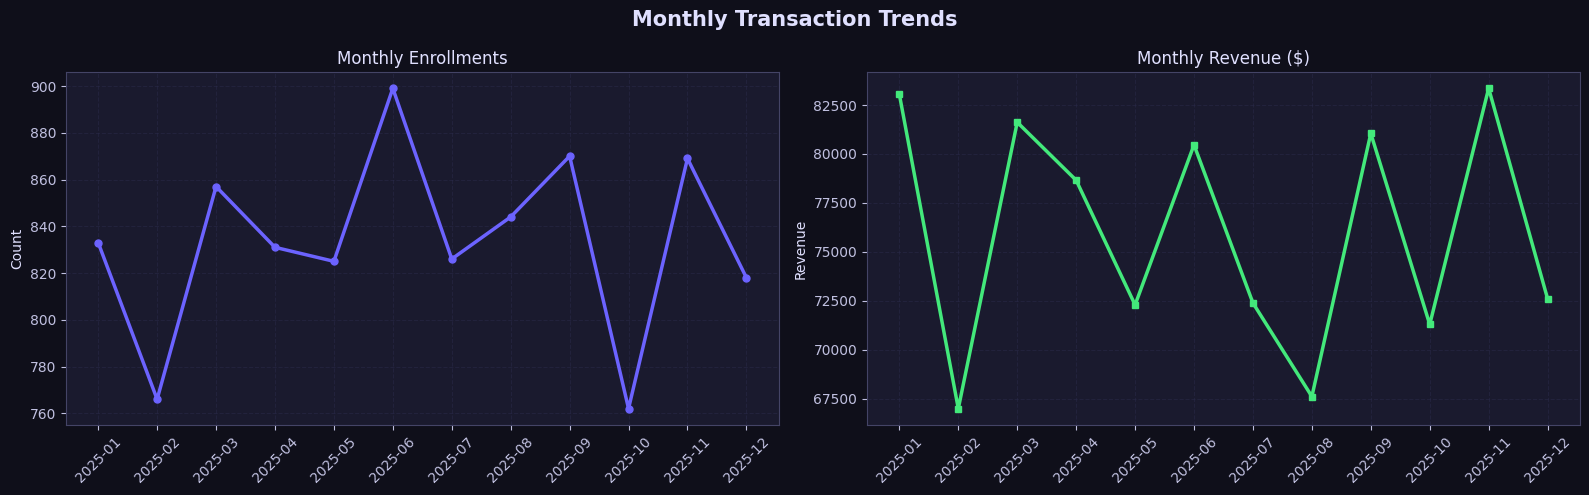

In [ ]:
# Transaction trends
trans_df['TransactionDate'] = pd.to_datetime(trans_df['TransactionDate'])
trans_df['YearMonth'] = trans_df['TransactionDate'].dt.to_period('M')

monthly = trans_df.groupby('YearMonth').agg(
    Enrollments=('TransactionID', 'count'),
    Revenue=('Amount', 'sum')
).reset_index()
monthly['YearMonth_str'] = monthly['YearMonth'].astype(str)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("Monthly Transaction Trends", fontsize=15, fontweight='bold', color='#e0e0ff')

ax = axes[0]
ax.plot(monthly['YearMonth_str'], monthly['Enrollments'],
        color='#6c63ff', linewidth=2.5, marker='o', markersize=5)
ax.set_title("Monthly Enrollments"); ax.set_ylabel("Count")
ax.tick_params(axis='x', rotation=45); ax.grid(True)

ax = axes[1]
ax.plot(monthly['YearMonth_str'], monthly['Revenue'],
        color='#43e97b', linewidth=2.5, marker='s', markersize=5)
ax.set_title("Monthly Revenue ($)"); ax.set_ylabel("Revenue")
ax.tick_params(axis='x', rotation=45); ax.grid(True)

plt.tight_layout()
# Create the output directory if it doesn't exist
import os
os.makedirs('/mnt/user-data/outputs/', exist_ok=True)
plt.savefig('/mnt/user-data/outputs/monthly_trends.png', dpi=150, bbox_inches='tight',
            facecolor='#0f0f1a')
plt.show()

## ⚙️ Section 4 – Feature Engineering (Learner Profiles)

In [ ]:
# ── Merge transactions with courses ──────────────────────────────────────────
merged = trans_df.merge(courses_df[['CourseID','CourseCategory','CourseLevel',
                                     'CourseType','CourseRating','CoursePrice']],
                        on='CourseID', how='left')
merged = merged.merge(users_df[['UserID','Age','Gender']], on='UserID', how='left')

print(f"Merged shape: {merged.shape}")
display(merged.head(3))


Merged shape: (10000, 15)


,TransactionID,UserID,CourseID,TransactionDate,Amount,PaymentMethod,TeacherID,YearMonth,CourseCategory,CourseLevel,CourseType,CourseRating,CoursePrice,Age,Gender
0,TT00001,U00003,CR00016,2025-10-25,0.0,PayPal,TC00040,2025-10,Marketing,Intermediate,Free,4.72,0.0,33,Female
1,TT00002,U00003,CR00037,2025-01-13,0.0,PayPal,TC00040,2025-01,Project Management,Intermediate,Free,3.45,0.0,33,Female
2,TT00003,U00003,CR00019,2025-03-28,0.0,Bank Transfer,TC00040,2025-03,Marketing,Advanced,Free,2.98,0.0,33,Female


In [ ]:
# ── Learner-level aggregation ─────────────────────────────────────────────────
def top_value(series):
    return series.mode()[0] if not series.mode().empty else np.nan

learner_profiles = merged.groupby('UserID').agg(
    total_enrollments      = ('CourseID',       'count'),
    total_spending         = ('Amount',          'sum'),
    avg_spending           = ('Amount',          'mean'),
    avg_course_rating      = ('CourseRating',    'mean'),
    preferred_category     = ('CourseCategory',  top_value),
    preferred_level        = ('CourseLevel',     top_value),
    diversity_score        = ('CourseCategory',  'nunique'),
    n_free                 = ('CourseType',      lambda x: (x == 'Free').sum()),
    n_paid                 = ('CourseType',      lambda x: (x == 'Paid').sum()),
    first_enrollment       = ('TransactionDate', 'min'),
    last_enrollment        = ('TransactionDate', 'max'),
    age                    = ('Age',             'first'),
    gender                 = ('Gender',          'first'),
).reset_index()

# ── Behavioral derived features ───────────────────────────────────────────────
learner_profiles['enrollment_span_days'] = (
    learner_profiles['last_enrollment'] - learner_profiles['first_enrollment']
).dt.days.clip(lower=1)

learner_profiles['enrollment_frequency'] = (
    learner_profiles['total_enrollments'] / learner_profiles['enrollment_span_days']
)

learner_profiles['paid_ratio'] = (
    learner_profiles['n_paid'] / learner_profiles['total_enrollments'].clip(lower=1)
)

# Learning-depth index: fraction of advanced/intermediate courses
level_counts = merged.groupby(['UserID','CourseLevel']).size().unstack(fill_value=0)
for lv in ['Beginner','Intermediate','Advanced']:
    if lv not in level_counts.columns:
        level_counts[lv] = 0
level_counts['learning_depth_index'] = (
    (level_counts.get('Advanced',0) + level_counts.get('Intermediate',0)) /
    level_counts[['Beginner','Intermediate','Advanced']].sum(axis=1).clip(lower=1)
)
learner_profiles = learner_profiles.merge(
    level_counts[['learning_depth_index']], on='UserID', how='left')

print(f"Learner profiles: {learner_profiles.shape}")
display(learner_profiles.head(5))


Learner profiles: (3000, 18)


,UserID,total_enrollments,total_spending,avg_spending,avg_course_rating,preferred_category,preferred_level,diversity_score,n_free,n_paid,first_enrollment,last_enrollment,age,gender,enrollment_span_days,enrollment_frequency,paid_ratio,learning_depth_index
0,U00001,1,394.26,394.260000,1.350000,Cybersecurity,Intermediate,1,0,1,2025-11-02,2025-11-02,15,Male,1,1.000000,1.000000,1.000000
1,U00002,1,0.00,0.000000,2.880000,Programming,Beginner,1,1,0,2025-07-15,2025-07-15,29,Female,1,1.000000,0.000000,0.000000
2,U00003,11,613.98,55.816364,2.889091,Marketing,Advanced,7,8,3,2025-01-13,2025-11-16,33,Female,307,0.035831,0.272727,0.636364
3,U00004,13,982.05,75.542308,3.451538,Digital Marketing,Intermediate,8,8,5,2025-01-06,2025-11-23,23,Female,321,0.040498,0.384615,0.692308
4,U00005,2,346.71,173.355000,2.055000,Programming,Advanced,2,1,1,2025-09-11,2025-12-03,21,Male,83,0.024096,0.500000,0.500000


In [ ]:
# ── Descriptive statistics of engineered features ─────────────────────────────
feat_cols = ['total_enrollments','total_spending','avg_spending',
             'avg_course_rating','diversity_score','enrollment_frequency',
             'paid_ratio','learning_depth_index']
print(learner_profiles[feat_cols].describe().round(3))


       total_enrollments  total_spending  avg_spending  avg_course_rating  \
count           3000.000        3000.000      3000.000           3000.000   
mean               3.333         303.774        89.345              3.133   
std                4.352         482.514       125.055              0.950   
min                1.000           0.000         0.000              1.130   
25%                1.000           0.000         0.000              2.570   
50%                1.000          53.860        26.930              3.123   
75%                3.000         415.510       133.465              3.795   
max               16.000        3054.370       490.900              4.940   

       diversity_score  enrollment_frequency  paid_ratio  learning_depth_index  
count         3000.000              3000.000    3000.000              3000.000  
mean             2.577                 0.563       0.350                 0.650  
std              2.728                 0.484       0.393       

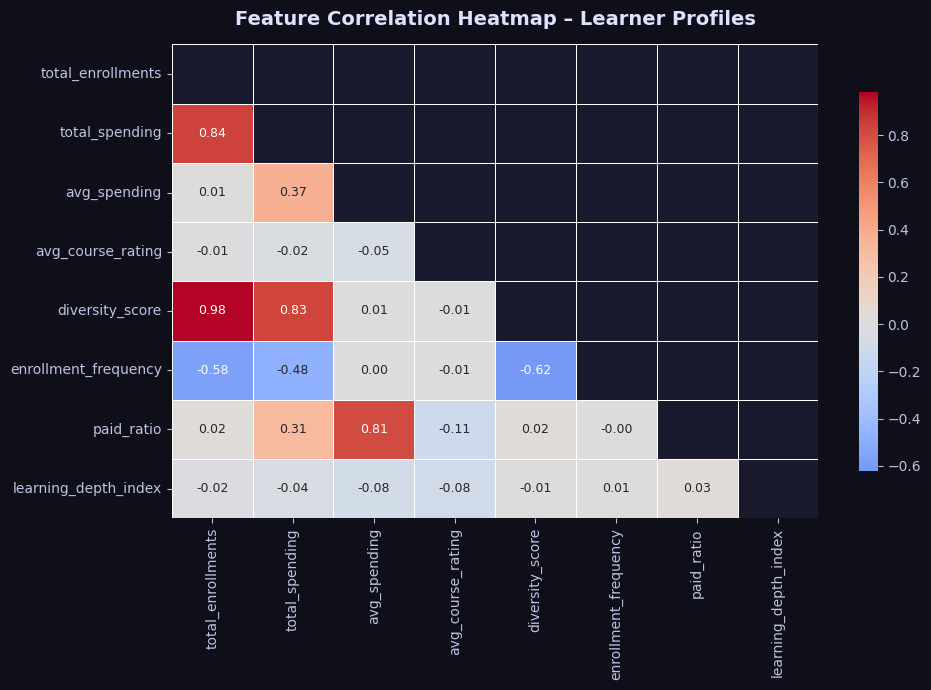

In [ ]:
# ── Feature correlation heatmap ───────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 7))
corr = learner_profiles[feat_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, ax=ax, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, linewidths=0.5,
            annot_kws={'size':9},
            cbar_kws={'shrink':0.8})
ax.set_title("Feature Correlation Heatmap – Learner Profiles",
             fontsize=14, fontweight='bold', pad=14)
plt.tight_layout()
plt.savefig('/mnt/user-data/outputs/feature_correlation.png', dpi=150,
            bbox_inches='tight', facecolor='#0f0f1a')
plt.show()


## 🔧 Section 5 – Data Preprocessing for Clustering

In [ ]:
# ── Select & scale clustering features ───────────────────────────────────────
cluster_features = ['total_enrollments','avg_spending','avg_course_rating',
                    'diversity_score','enrollment_frequency','paid_ratio',
                    'learning_depth_index']

X_raw = learner_profiles[cluster_features].fillna(0)
print(f"Clustering matrix: {X_raw.shape}")

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)
print("✅ Features standardised  (mean≈0, std≈1)")
print(pd.DataFrame(X_scaled, columns=cluster_features).describe().round(3))


Clustering matrix: (3000, 7)
✅ Features standardised  (mean≈0, std≈1)
       total_enrollments  avg_spending  avg_course_rating  diversity_score  \
count           3000.000      3000.000           3000.000         3000.000   
mean              -0.000        -0.000             -0.000           -0.000   
std                1.000         1.000              1.000            1.000   
min               -0.536        -0.715             -2.109           -0.578   
25%               -0.536        -0.715             -0.593           -0.578   
50%               -0.536        -0.499             -0.011           -0.578   
75%               -0.077         0.353              0.696           -0.212   
max                2.911         3.212              1.902            3.088   

       enrollment_frequency  paid_ratio  learning_depth_index  
count              3000.000    3000.000              3000.000  
mean                 -0.000      -0.000                 0.000  
std                   1.000       1

## 🔵 Section 6 – Learner Segmentation (K-Means Clustering)

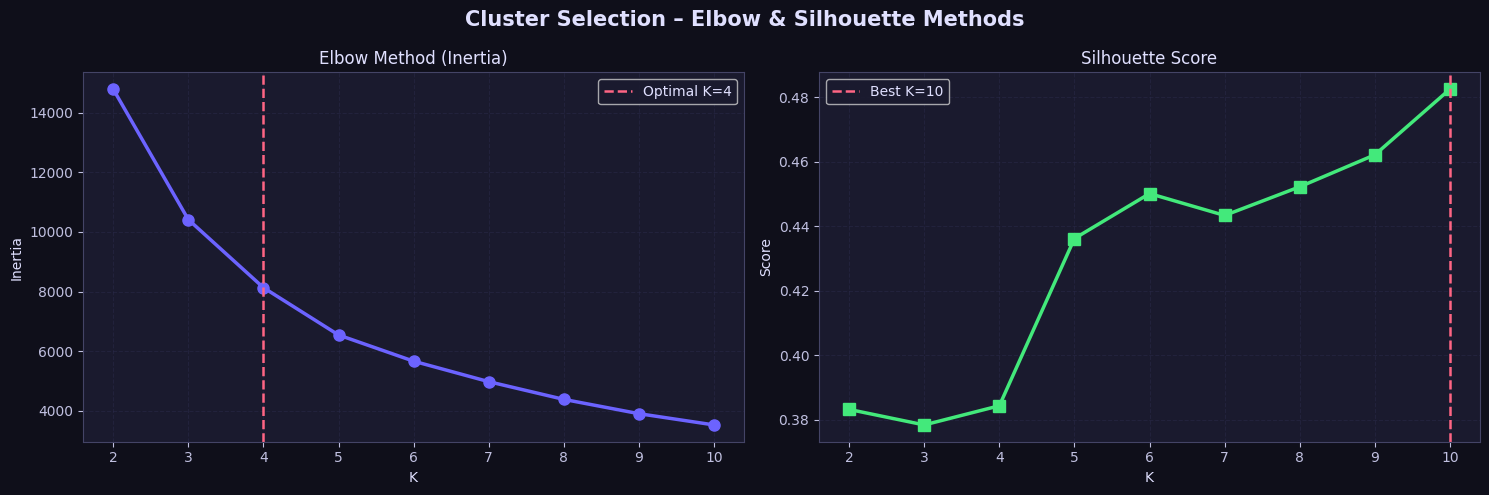


Best K by Silhouette: 10  |  Score: 0.4825


In [ ]:
# ── Elbow Method ──────────────────────────────────────────────────────────────
inertias, silhouettes = [], []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=15, random_state=42)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle("Cluster Selection – Elbow & Silhouette Methods",
             fontsize=15, fontweight='bold', color='#e0e0ff')

# Elbow
ax = axes[0]
ax.plot(list(K_range), inertias, color='#6c63ff', linewidth=2.5,
        marker='o', markersize=8)
ax.axvline(x=4, color='#ff6584', linestyle='--', linewidth=1.8, label='Optimal K=4')
ax.set_title("Elbow Method (Inertia)"); ax.set_xlabel("K"); ax.set_ylabel("Inertia")
ax.legend(); ax.grid(True)

# Silhouette
ax = axes[1]
ax.plot(list(K_range), silhouettes, color='#43e97b', linewidth=2.5,
        marker='s', markersize=8)
best_k = list(K_range)[silhouettes.index(max(silhouettes))]
ax.axvline(x=best_k, color='#ff6584', linestyle='--',
           linewidth=1.8, label=f'Best K={best_k}')
ax.set_title("Silhouette Score"); ax.set_xlabel("K"); ax.set_ylabel("Score")
ax.legend(); ax.grid(True)

plt.tight_layout()
plt.savefig('/mnt/user-data/outputs/elbow_silhouette.png', dpi=150,
            bbox_inches='tight', facecolor='#0f0f1a')
plt.show()

print(f"\nBest K by Silhouette: {best_k}  |  Score: {max(silhouettes):.4f}")


In [ ]:
# ── Final K-Means Model ───────────────────────────────────────────────────────
OPTIMAL_K = 4
kmeans = KMeans(n_clusters=OPTIMAL_K, init='k-means++', n_init=20, random_state=42)
learner_profiles['Cluster'] = kmeans.fit_predict(X_scaled)

sil_score = silhouette_score(X_scaled, learner_profiles['Cluster'])
print(f"✅ K-Means fitted  |  K={OPTIMAL_K}  |  Silhouette Score = {sil_score:.4f}")
print("\nCluster Sizes:")
print(learner_profiles['Cluster'].value_counts().sort_index())


✅ K-Means fitted  |  K=4  |  Silhouette Score = 0.3844

Cluster Sizes:
Cluster
0    1067
1     616
2     454
3     863
Name: count, dtype: int64


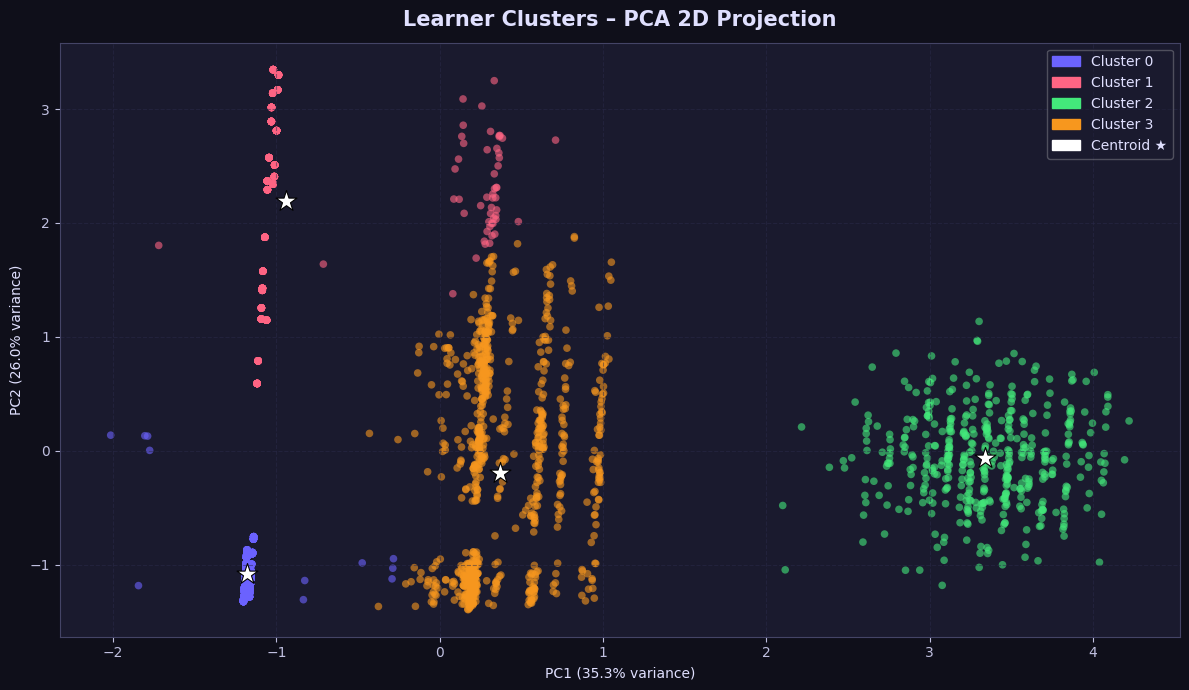

Explained variance: PC1=35.32%, PC2=26.01%


In [ ]:
# ── PCA Visualisation ────────────────────────────────────────────────────────
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
learner_profiles['PCA1'] = X_pca[:, 0]
learner_profiles['PCA2'] = X_pca[:, 1]

fig, ax = plt.subplots(figsize=(12, 7))
scatter_colors = [PALETTE[c] for c in learner_profiles['Cluster']]
sc = ax.scatter(X_pca[:, 0], X_pca[:, 1], c=scatter_colors,
                s=30, alpha=0.6, edgecolors='none')

# Plot centroids
centroids_pca = pca.transform(kmeans.cluster_centers_)
ax.scatter(centroids_pca[:, 0], centroids_pca[:, 1],
           c='white', s=250, marker='*', zorder=5,
           edgecolors='black', linewidth=0.8, label='Centroids')

patches = [mpatches.Patch(color=PALETTE[i], label=f'Cluster {i}')
           for i in range(OPTIMAL_K)]
patches.append(mpatches.Patch(color='white', label='Centroid ★'))
ax.legend(handles=patches, loc='upper right', framealpha=0.3)
ax.set_title("Learner Clusters – PCA 2D Projection",
             fontsize=15, fontweight='bold', pad=12)
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)")
ax.grid(True)
plt.tight_layout()
plt.savefig('/mnt/user-data/outputs/pca_clusters.png', dpi=150,
            bbox_inches='tight', facecolor='#0f0f1a')
plt.show()
print(f"Explained variance: PC1={pca.explained_variance_ratio_[0]:.2%}, "
      f"PC2={pca.explained_variance_ratio_[1]:.2%}")


## 🌳 Section 7 – Hierarchical Clustering (Validation)

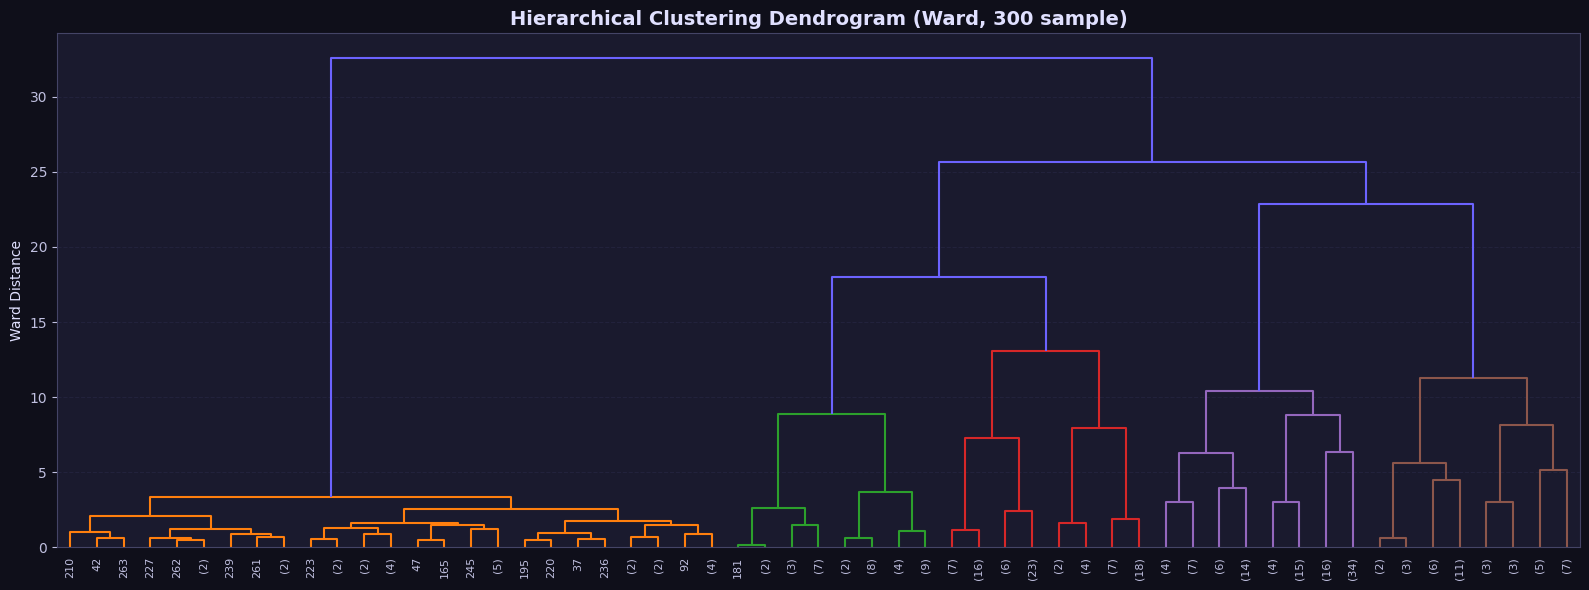


Hierarchical Clustering Silhouette Score (K=4): 0.3855
K-Means Silhouette Score                 (K=4): 0.3844


In [ ]:
# Use a sample for dendrogram clarity
np.random.seed(42)
sample_idx = np.random.choice(len(X_scaled), size=300, replace=False)
X_sample = X_scaled[sample_idx]

Z = linkage(X_sample, method='ward')

fig, ax = plt.subplots(figsize=(16, 6))
dendrogram(Z, ax=ax, truncate_mode='level', p=5,
           leaf_font_size=8, color_threshold=15,
           above_threshold_color='#6c63ff')
ax.set_title("Hierarchical Clustering Dendrogram (Ward, 300 sample)",
             fontsize=14, fontweight='bold')
ax.set_ylabel("Ward Distance"); ax.grid(True, axis='y')
plt.tight_layout()
plt.savefig('/mnt/user-data/outputs/dendrogram.png', dpi=150,
            bbox_inches='tight', facecolor='#0f0f1a')
plt.show()

# Validate with AgglomerativeClustering
hc = AgglomerativeClustering(n_clusters=OPTIMAL_K, linkage='ward')
hc_labels = hc.fit_predict(X_scaled)
hc_sil = silhouette_score(X_scaled, hc_labels)
print(f"\nHierarchical Clustering Silhouette Score (K={OPTIMAL_K}): {hc_sil:.4f}")
print(f"K-Means Silhouette Score                 (K={OPTIMAL_K}): {sil_score:.4f}")


## 📊 Section 8 – Cluster Profiling & Learner Persona Analysis

In [ ]:
# ── Cluster summary statistics ────────────────────────────────────────────────
profile_summary = learner_profiles.groupby('Cluster')[
    cluster_features + ['age']
].agg(['mean','median']).round(3)
display(profile_summary)


total_enrollments        avg_spending          avg_course_rating  \
                     mean median         mean   median              mean   
Cluster                                                                    
0                   1.010    1.0        0.151    0.000             3.220   
1                   1.089    1.0      262.370  289.500             2.954   
2                  13.405   13.0       93.243   90.593             3.114   
3                   2.509    2.0       74.069   44.335             3.164   

               diversity_score        enrollment_frequency        paid_ratio  \
        median            mean median                 mean median       mean   
Cluster                                                                        
0        3.320           1.009    1.0                1.003  1.000      0.002   
1        2.750           1.075    1.0                0.924  1.000      1.000   
2        3.108           8.731    9.0                0.043  0.042      0.368   
3        3.160           2.351    2.0                0.036  0.019      0.307   

               learning_depth_index            age         
        median                 mean median    mean median  
Cluster                                                    
0        0.000                0.650  1.000  25.321   26.0  
1        1.000                0.662  1.000  24.532   25.0  
2        0.364                0.636  0.643  24.947   25.0  
3        0.333                0.650  0.667  24.875   25.0

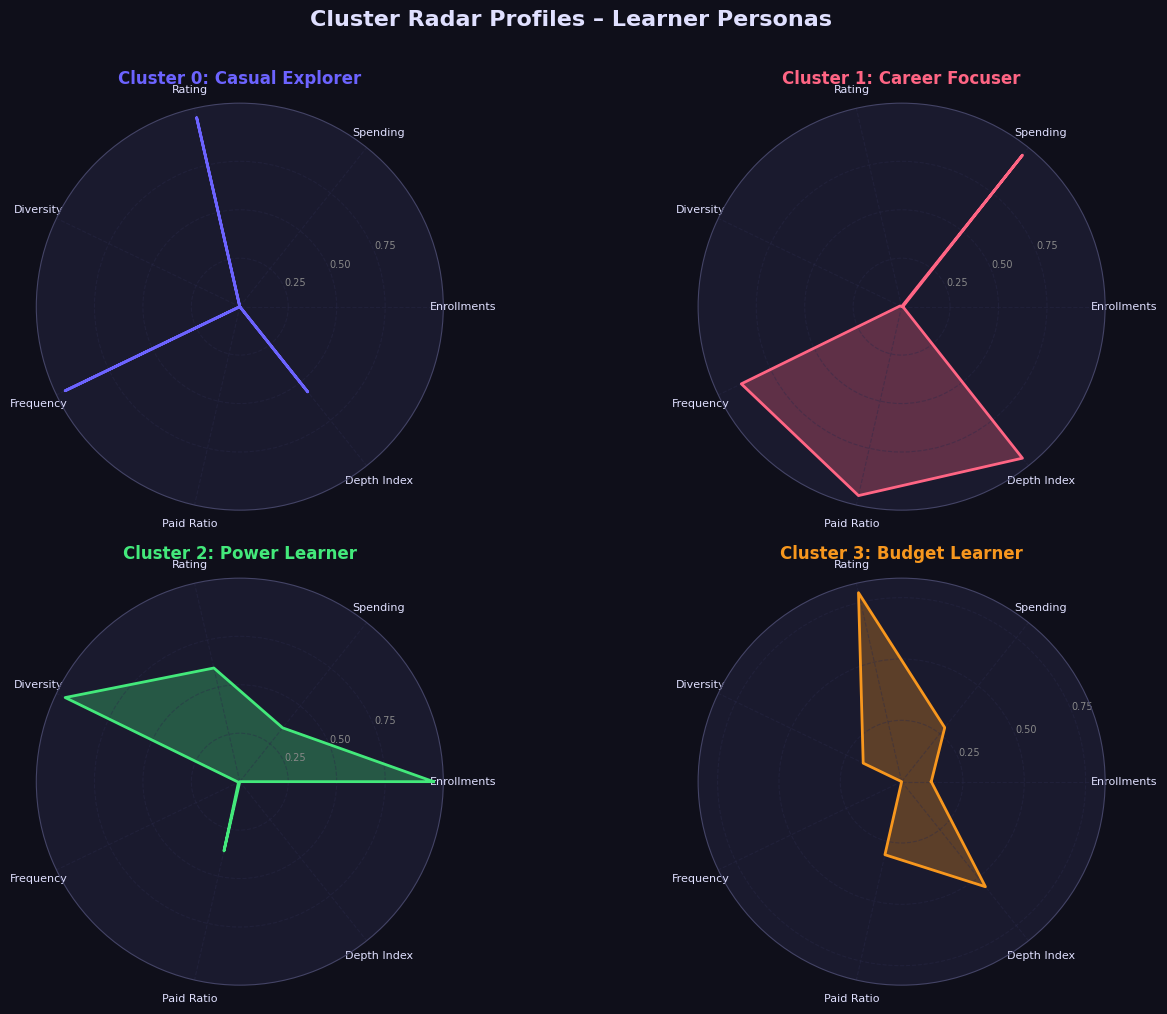

In [ ]:
# ── Radar chart for cluster comparison ───────────────────────────────────────
from matplotlib.patches import FancyArrowPatch
import matplotlib.gridspec as gridspec

radar_features = ['total_enrollments','avg_spending','avg_course_rating',
                  'diversity_score','enrollment_frequency',
                  'paid_ratio','learning_depth_index']

# Normalize to 0-1 for radar
means = learner_profiles.groupby('Cluster')[radar_features].mean()
norm_means = (means - means.min()) / (means.max() - means.min() + 1e-9)

angles = np.linspace(0, 2 * np.pi, len(radar_features), endpoint=False).tolist()
angles += angles[:1]

labels_short = ['Enrollments','Spending','Rating','Diversity',
                'Frequency','Paid Ratio','Depth Index']

fig, axes = plt.subplots(2, 2, figsize=(14, 10),
                          subplot_kw=dict(polar=True))
fig.suptitle("Cluster Radar Profiles – Learner Personas",
             fontsize=16, fontweight='bold', color='#e0e0ff', y=1.01)

cluster_names = ['Casual Explorer','Career Focuser',
                 'Power Learner','Budget Learner']

for i, ax in enumerate(axes.flatten()):
    values = norm_means.iloc[i].tolist()
    values += values[:1]
    ax.plot(angles, values, color=PALETTE[i], linewidth=2)
    ax.fill(angles, values, color=PALETTE[i], alpha=0.3)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(labels_short, size=8, color='#e0e0ff')
    ax.set_yticks([0.25, 0.5, 0.75])
    ax.set_yticklabels(['0.25','0.50','0.75'], size=7, color='#888')
    ax.set_title(f"Cluster {i}: {cluster_names[i]}",
                 size=12, fontweight='bold', pad=14, color=PALETTE[i])
    ax.grid(True, alpha=0.4)
    ax.set_facecolor('#1a1a2e')

plt.tight_layout()
plt.savefig('/mnt/user-data/outputs/radar_clusters.png', dpi=150,
            bbox_inches='tight', facecolor='#0f0f1a')
plt.show()


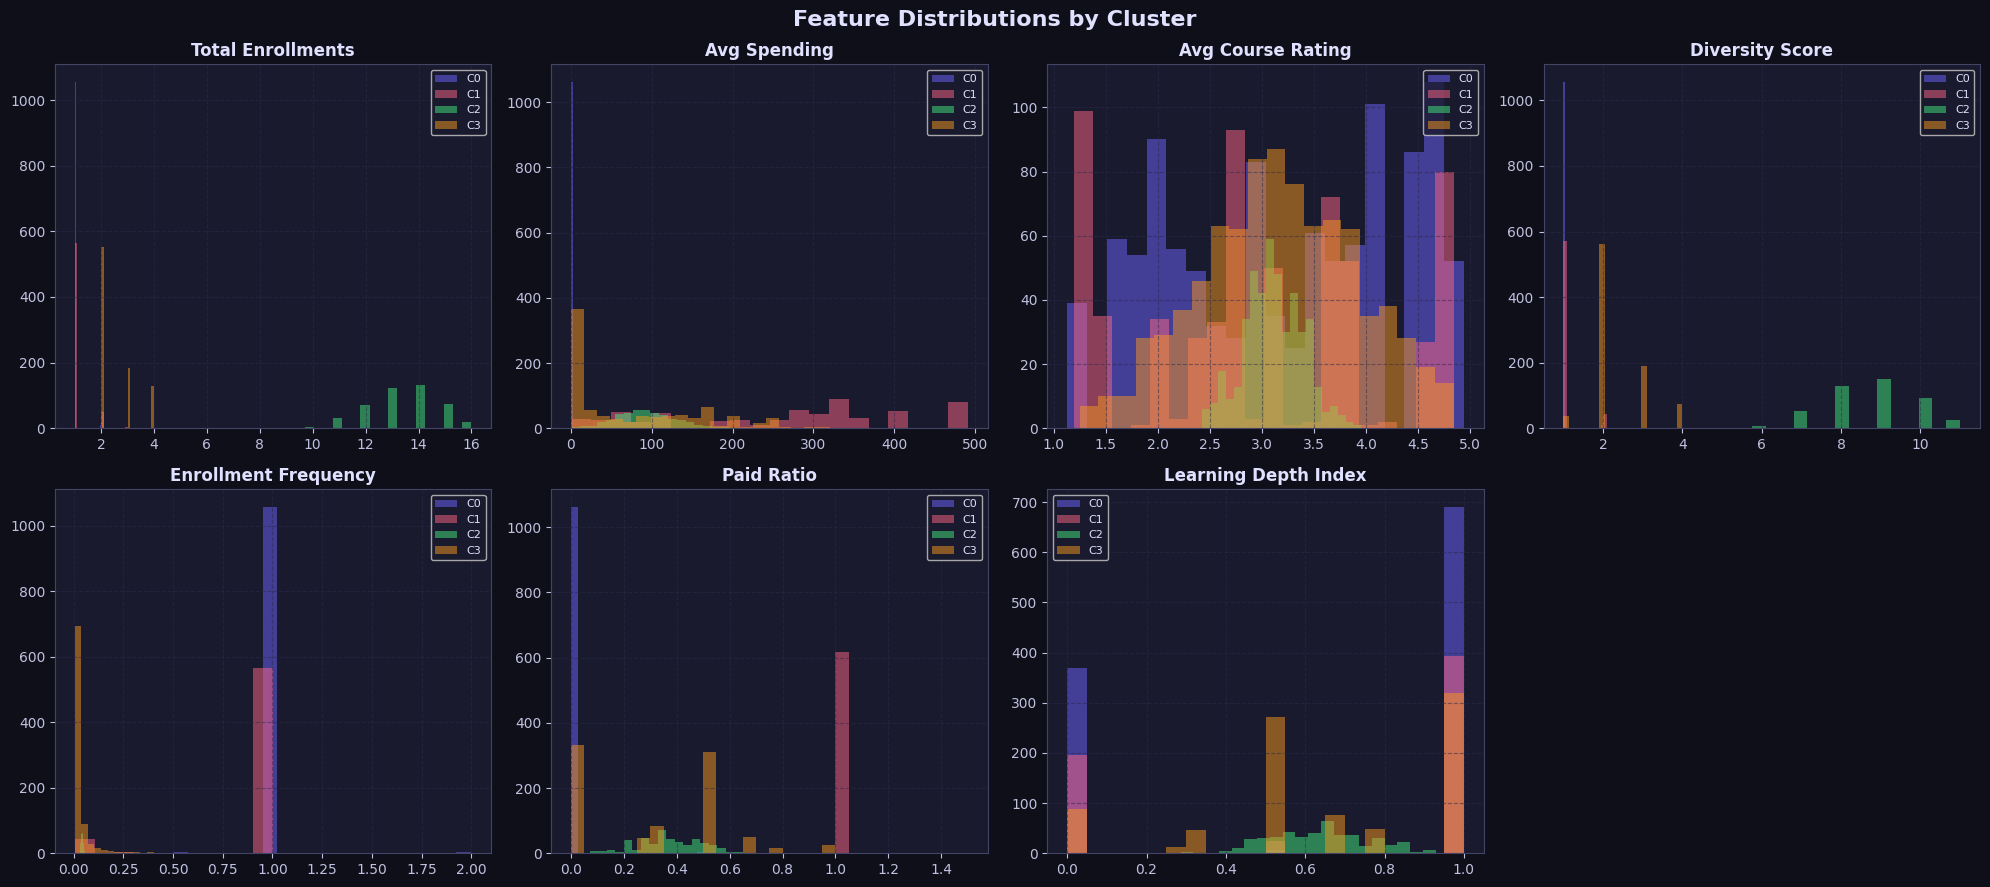

In [ ]:
# ── Feature distributions per cluster ────────────────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(20, 9))
fig.suptitle("Feature Distributions by Cluster",
             fontsize=16, fontweight='bold', color='#e0e0ff')

for idx, feat in enumerate(cluster_features):
    ax = axes[idx // 4][idx % 4]
    for cl in range(OPTIMAL_K):
        data = learner_profiles[learner_profiles['Cluster'] == cl][feat]
        ax.hist(data, bins=20, alpha=0.5, color=PALETTE[cl],
                label=f'C{cl}', edgecolor='none')
    ax.set_title(feat.replace('_',' ').title(), fontweight='bold')
    ax.legend(fontsize=8); ax.grid(True)

# Hide unused subplot
axes[1][3].set_visible(False)
plt.tight_layout()
plt.savefig('/mnt/user-data/outputs/feature_distributions.png', dpi=150,
            bbox_inches='tight', facecolor='#0f0f1a')
plt.show()


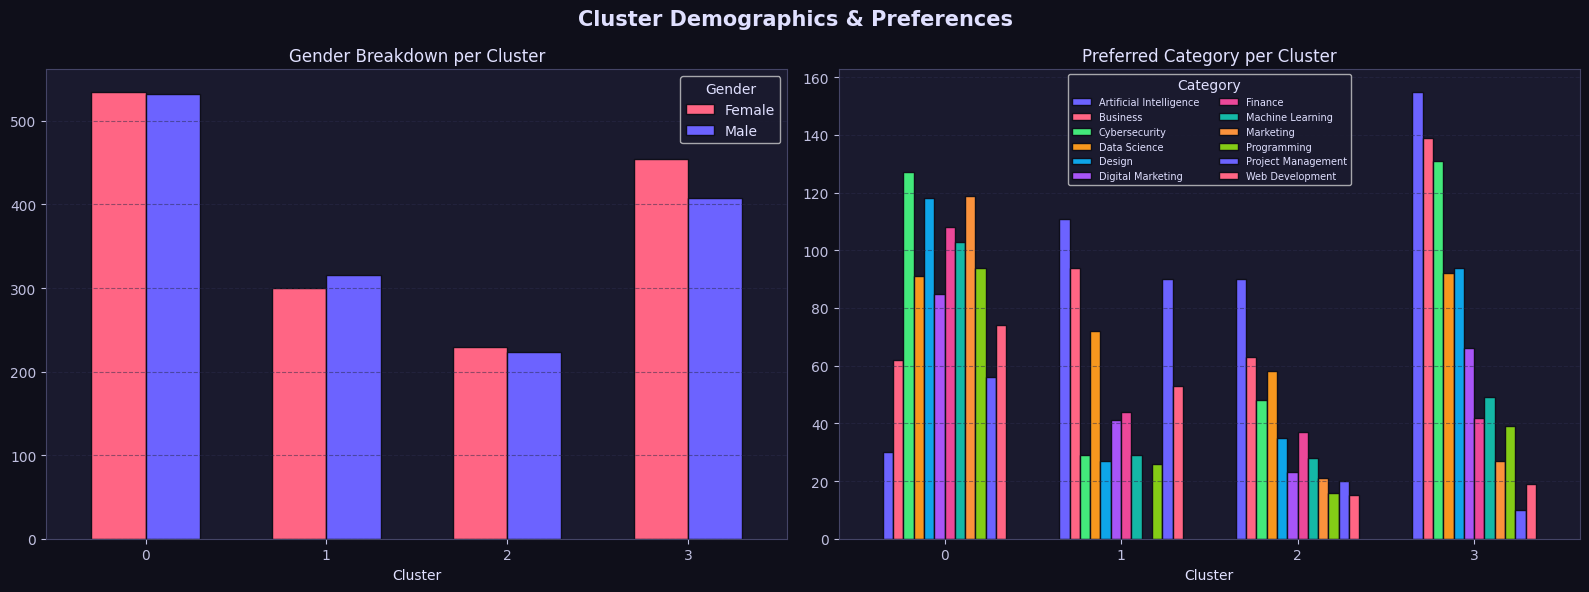

In [ ]:
# ── Gender & Category breakdown per cluster ───────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Cluster Demographics & Preferences",
             fontsize=15, fontweight='bold', color='#e0e0ff')

# Gender per cluster
gender_pivot = learner_profiles.groupby(['Cluster','gender']).size().unstack(fill_value=0)
gender_pivot.plot(kind='bar', ax=axes[0], color=['#ff6584','#6c63ff','#43e97b'],
                  edgecolor='#0f0f1a', width=0.6)
axes[0].set_title("Gender Breakdown per Cluster"); axes[0].set_xlabel("Cluster")
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)
axes[0].grid(True, axis='y'); axes[0].legend(title='Gender')

# Preferred category per cluster
cat_pivot = learner_profiles.groupby(['Cluster','preferred_category']).size().unstack(fill_value=0)
cat_pivot.plot(kind='bar', ax=axes[1], color=PALETTE[:cat_pivot.shape[1]],
               edgecolor='#0f0f1a', width=0.7)
axes[1].set_title("Preferred Category per Cluster"); axes[1].set_xlabel("Cluster")
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)
axes[1].grid(True, axis='y'); axes[1].legend(title='Category', fontsize=7, ncol=2)

plt.tight_layout()
plt.savefig('/mnt/user-data/outputs/cluster_demographics.png', dpi=150,
            bbox_inches='tight', facecolor='#0f0f1a')
plt.show()


## 📐 Section 9 – Silhouette Analysis (Cluster Quality Evaluation)

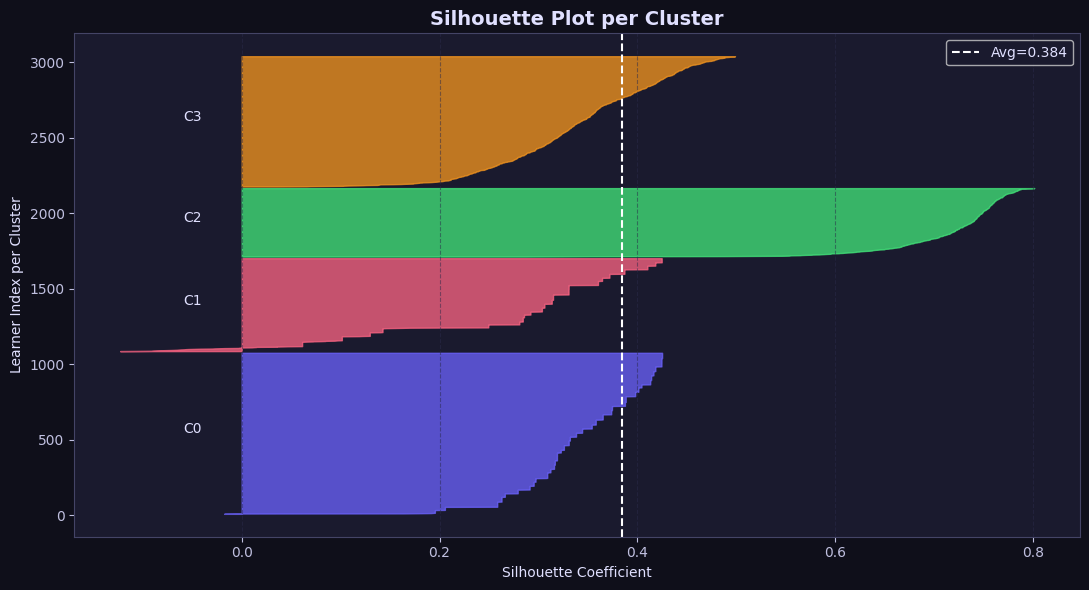


Overall Silhouette Score: 0.3844

Per-Cluster Average Silhouette Scores:
  Cluster 0 (Casual Explorer): 0.3433  (n=1067)
  Cluster 1 (Career Focuser): 0.2708  (n=616)
  Cluster 2 (Power Learner): 0.7183  (n=454)
  Cluster 3 (Budget Learner): 0.3406  (n=863)


In [ ]:
from sklearn.metrics import silhouette_samples

sample_sil = silhouette_samples(X_scaled, learner_profiles['Cluster'])
learner_profiles['silhouette'] = sample_sil

fig, ax = plt.subplots(figsize=(11, 6))
y_lower = 10
for i in range(OPTIMAL_K):
    vals = np.sort(sample_sil[learner_profiles['Cluster'] == i])
    size = len(vals)
    y_upper = y_lower + size
    color = PALETTE[i]
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, vals,
                     facecolor=color, edgecolor=color, alpha=0.75)
    ax.text(-0.05, y_lower + size / 2, f'C{i}', ha='center', fontsize=10)
    y_lower = y_upper + 10

ax.axvline(x=sil_score, color='white', linestyle='--', linewidth=1.5,
           label=f'Avg={sil_score:.3f}')
ax.set_title("Silhouette Plot per Cluster", fontsize=14, fontweight='bold')
ax.set_xlabel("Silhouette Coefficient")
ax.set_ylabel("Learner Index per Cluster")
ax.legend(); ax.grid(True, axis='x')
plt.tight_layout()
plt.savefig('/mnt/user-data/outputs/silhouette_plot.png', dpi=150,
            bbox_inches='tight', facecolor='#0f0f1a')
plt.show()

print(f"\nOverall Silhouette Score: {sil_score:.4f}")
print("\nPer-Cluster Average Silhouette Scores:")
for i in range(OPTIMAL_K):
    vals = sample_sil[learner_profiles['Cluster'] == i]
    print(f"  Cluster {i} ({cluster_names[i]}): {vals.mean():.4f}  (n={len(vals)})")


## 🎯 Section 10 – Personalized Course Recommendation Engine

In [ ]:
# ── Build cluster-course affinity matrix ─────────────────────────────────────
user_cluster_map = learner_profiles[['UserID','Cluster']].set_index('UserID')['Cluster']
merged['Cluster'] = merged['UserID'].map(user_cluster_map)

cluster_course_stats = merged.groupby(['Cluster','CourseID']).agg(
    enrollments  = ('TransactionID', 'count'),
    avg_rating   = ('CourseRating',  'mean'),
).reset_index()

# Weighted popularity score = enrollments * avg_rating
cluster_course_stats['popularity_score'] = (
    cluster_course_stats['enrollments'] * cluster_course_stats['avg_rating']
)

print("Cluster-Course Affinity Matrix:")
display(cluster_course_stats.head(10))


Cluster-Course Affinity Matrix:


,Cluster,CourseID,enrollments,avg_rating,popularity_score
0,0,CR00002,20,2.43,48.60
1,0,CR00003,28,3.85,107.80
2,0,CR00004,24,2.88,69.12
3,0,CR00005,22,1.28,28.16
4,0,CR00007,31,2.61,80.91
5,0,CR00008,28,1.52,42.56
6,0,CR00009,26,4.51,117.26
7,0,CR00010,34,4.45,151.30
8,0,CR00013,29,2.00,58.00
9,0,CR00014,34,3.15,107.10


In [ ]:
def recommend_courses(cluster_id, top_n=5, level_filter=None, category_filter=None):
    """
    Recommend top N courses for a given learner cluster.
    Optionally filter by CourseLevel and/or CourseCategory.
    """
    pool = cluster_course_stats[cluster_course_stats['Cluster'] == cluster_id].copy()

    # Merge with course metadata
    pool = pool.merge(
        courses_df[['CourseID','CourseName','CourseCategory','CourseLevel',
                    'CourseType','CoursePrice','CourseRating']],
        on='CourseID', how='left')

    if level_filter:
        pool = pool[pool['CourseLevel'] == level_filter]
    if category_filter:
        pool = pool[pool['CourseCategory'] == category_filter]

    recs = pool.sort_values('popularity_score', ascending=False).head(top_n)
    recs = recs[['CourseName','CourseCategory','CourseLevel','CourseType',
                 'CourseRating','enrollments','popularity_score']]
    recs['popularity_score'] = recs['popularity_score'].round(2)
    return recs.reset_index(drop=True)

# ── Test recommendations ──────────────────────────────────────────────────────
for cl in range(OPTIMAL_K):
    print(f"\n{'='*60}")
    print(f"  TOP 5 RECOMMENDATIONS – Cluster {cl}: {cluster_names[cl]}")
    print('='*60)
    display(recommend_courses(cl, top_n=5))



  TOP 5 RECOMMENDATIONS – Cluster 0: Casual Explorer


,CourseName,CourseCategory,CourseLevel,CourseType,CourseRating,enrollments,popularity_score
0,Cyber Threat Intelligence,Cybersecurity,Beginner,Free,4.94,34,167.96
1,Investment Strategies,Finance,Intermediate,Free,4.10,39,159.90
2,Corporate Finance,Finance,Beginner,Free,4.14,37,153.18
3,3D Modeling,Design,Advanced,Free,4.45,34,151.30
4,Intro to Machine Learning,Machine Learning,Intermediate,Free,4.73,31,146.63



  TOP 5 RECOMMENDATIONS – Cluster 1: Career Focuser


,CourseName,CourseCategory,CourseLevel,CourseType,CourseRating,enrollments,popularity_score
0,Risk Management,Project Management,Intermediate,Paid,4.84,34,164.56
1,Statistical Analysis,Data Science,Beginner,Paid,3.74,43,160.82
2,Computer Vision,Artificial Intelligence,Beginner,Paid,4.55,35,159.25
3,Full-Stack Web Development,Web Development,Advanced,Paid,4.74,30,142.20
4,Business Strategy,Business,Advanced,Paid,3.64,37,134.68



  TOP 5 RECOMMENDATIONS – Cluster 2: Power Learner


,CourseName,CourseCategory,CourseLevel,CourseType,CourseRating,enrollments,popularity_score
0,Social Media Strategy,Digital Marketing,Beginner,Free,4.44,122,541.68
1,Agile Project Management,Project Management,Beginner,Free,4.68,113,528.84
2,Full-Stack Web Development,Web Development,Advanced,Paid,4.74,110,521.40
3,Python Basics,Programming,Beginner,Paid,4.74,109,516.66
4,Cyber Threat Intelligence,Cybersecurity,Beginner,Free,4.94,103,508.82



  TOP 5 RECOMMENDATIONS – Cluster 3: Budget Learner


,CourseName,CourseCategory,CourseLevel,CourseType,CourseRating,enrollments,popularity_score
0,SEO Mastery,Marketing,Advanced,Free,4.79,46,220.34
1,Affiliate Marketing,Digital Marketing,Intermediate,Free,4.66,47,219.02
2,Web Design Fundamentals,Design,Beginner,Free,4.51,47,211.97
3,Cyber Threat Intelligence,Cybersecurity,Beginner,Free,4.94,42,207.48
4,Social Media Strategy,Digital Marketing,Beginner,Free,4.44,45,199.80


In [ ]:
# ── Recommendation precision proxy (intra-cluster consistency) ────────────────
# For each cluster, measure how often the top-10 recommended courses
# appear in the actual enrollments of cluster members.

print("Recommendation Precision (Intra-Cluster Consistency)")
print("=" * 55)

for cl in range(OPTIMAL_K):
    top10 = recommend_courses(cl, top_n=10)['CourseName'].tolist()
    cluster_users = learner_profiles[learner_profiles['Cluster'] == cl]['UserID']
    actual_courses = merged[merged['UserID'].isin(cluster_users)]['CourseID']
    actual_names = courses_df.set_index('CourseID').loc[
        actual_courses.unique(), 'CourseName'].tolist()

    hits = len([c for c in top10 if c in actual_names])
    precision = hits / len(top10) if top10 else 0
    print(f"  Cluster {cl} ({cluster_names[cl]:<20}): precision = {precision:.2f}  "
          f"({hits}/{len(top10)} top-10 courses actually enrolled)")


Recommendation Precision (Intra-Cluster Consistency)
  Cluster 0 (Casual Explorer     ): precision = 1.00  (10/10 top-10 courses actually enrolled)
  Cluster 1 (Career Focuser      ): precision = 1.00  (10/10 top-10 courses actually enrolled)
  Cluster 2 (Power Learner       ): precision = 1.00  (10/10 top-10 courses actually enrolled)
  Cluster 3 (Budget Learner      ): precision = 1.00  (10/10 top-10 courses actually enrolled)


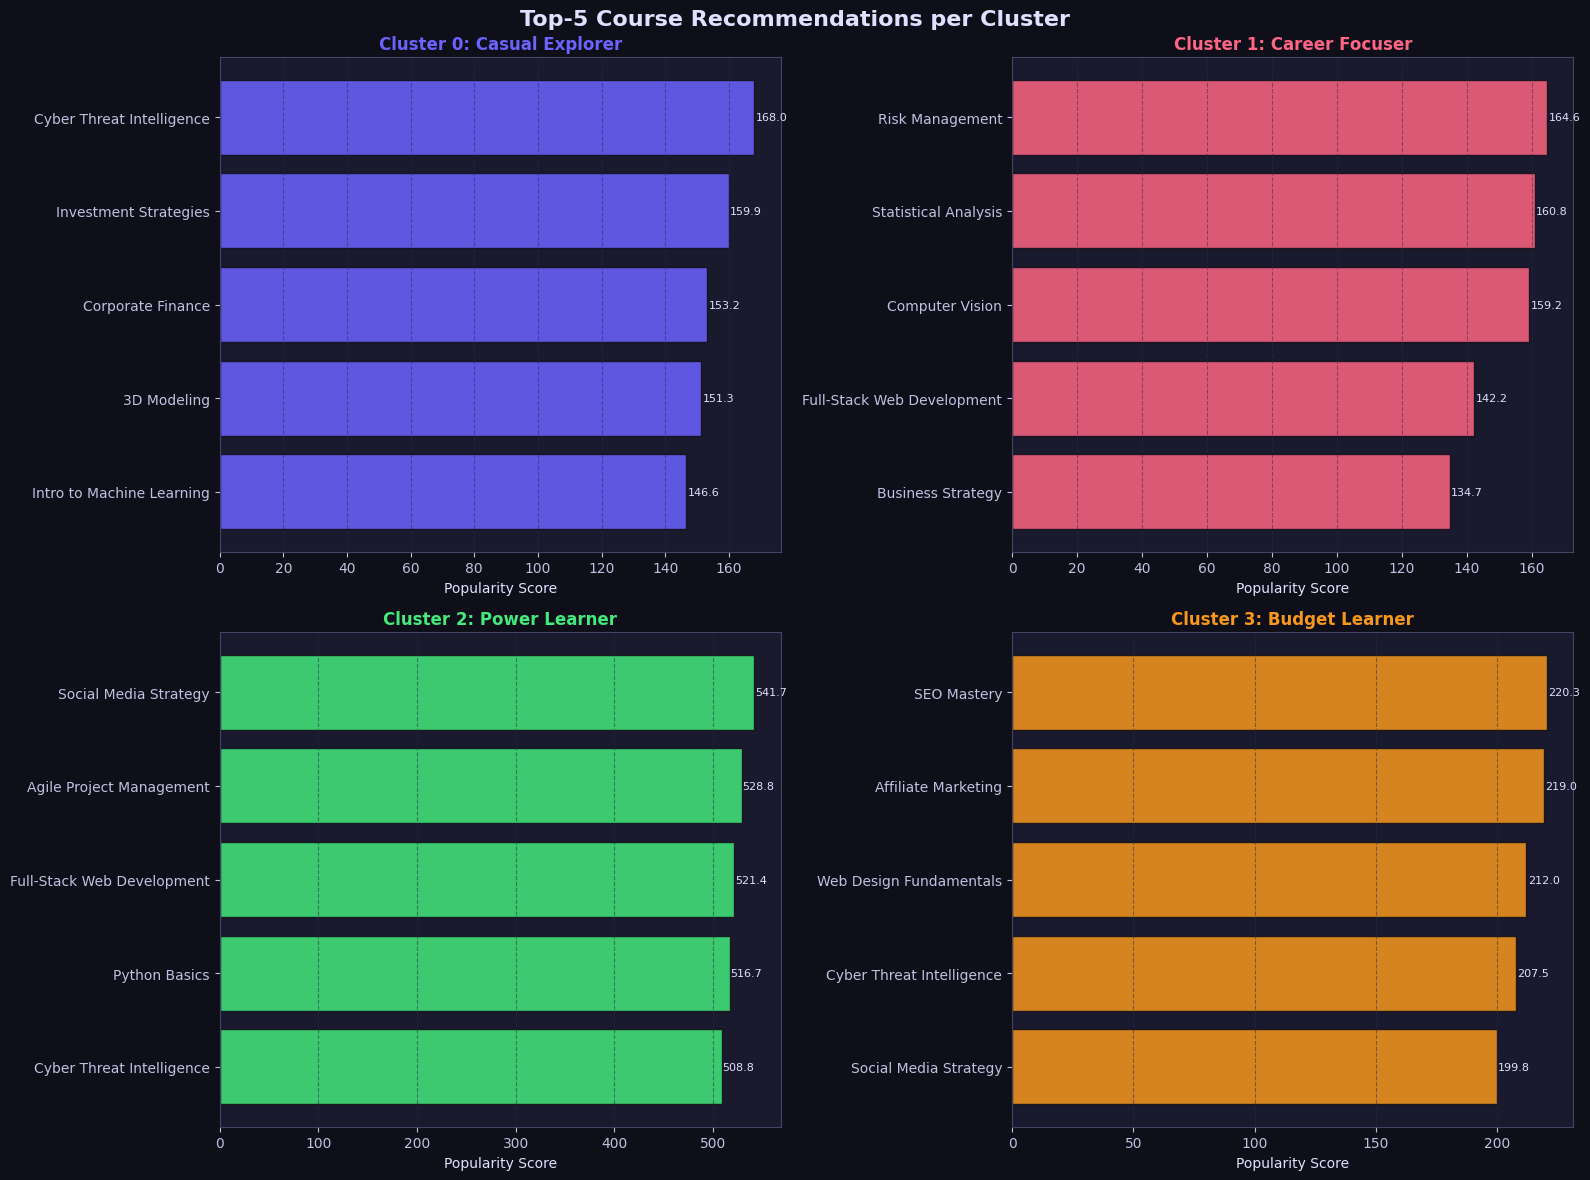

In [ ]:
# ── Visualize recommendation landscape ───────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("Top-5 Course Recommendations per Cluster",
             fontsize=16, fontweight='bold', color='#e0e0ff')

for cl, ax in enumerate(axes.flatten()):
    recs = recommend_courses(cl, top_n=5)
    bars = ax.barh(recs['CourseName'], recs['popularity_score'],
                   color=PALETTE[cl], edgecolor='#0f0f1a', alpha=0.85)
    ax.set_title(f"Cluster {cl}: {cluster_names[cl]}",
                 fontweight='bold', color=PALETTE[cl])
    ax.set_xlabel("Popularity Score"); ax.invert_yaxis()
    ax.grid(True, axis='x')
    for bar in bars:
        ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
                f'{bar.get_width():.1f}', va='center', fontsize=8)

plt.tight_layout()
plt.savefig('/mnt/user-data/outputs/recommendations.png', dpi=150,
            bbox_inches='tight', facecolor='#0f0f1a')
plt.show()


## 📈 Section 11 – Model Evaluation & Validation Summary

In [ ]:
# ── Intra-cluster similarity (mean pairwise cosine similarity) ────────────────
from sklearn.metrics.pairwise import cosine_similarity

print("Intra-Cluster Similarity (avg cosine sim within cluster)")
print("=" * 58)
for cl in range(OPTIMAL_K):
    idx = learner_profiles[learner_profiles['Cluster'] == cl].index
    sample = X_scaled[idx]
    if len(sample) > 500:
        np.random.seed(42)
        sample = sample[np.random.choice(len(sample), 500, replace=False)]
    sim_matrix = cosine_similarity(sample)
    np.fill_diagonal(sim_matrix, np.nan)
    avg_sim = np.nanmean(sim_matrix)
    print(f"  Cluster {cl} ({cluster_names[cl]:<20}): {avg_sim:.4f}")


Intra-Cluster Similarity (avg cosine sim within cluster)
  Cluster 0 (Casual Explorer     ): 0.5141
  Cluster 1 (Career Focuser      ): 0.5860
  Cluster 2 (Power Learner       ): 0.9607
  Cluster 3 (Budget Learner      ): 0.3838


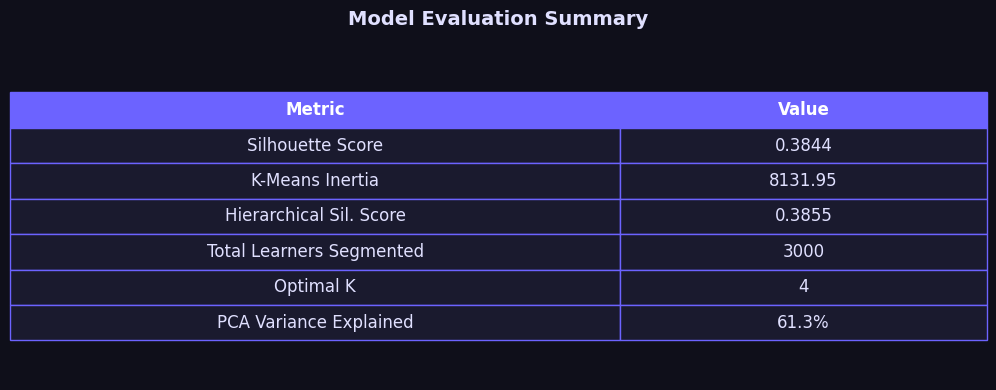


Evaluation Metrics:
  Silhouette Score                   : 0.3844
  K-Means Inertia                    : 8131.95
  Hierarchical Sil. Score            : 0.3855
  Total Learners Segmented           : 3000
  Optimal K                          : 4
  PCA Variance Explained             : 61.3%


In [ ]:
# ── Final evaluation dashboard ───────────────────────────────────────────────
metrics = {
    'Silhouette Score'         : round(sil_score, 4),
    'K-Means Inertia'          : round(kmeans.inertia_, 2),
    'Hierarchical Sil. Score'  : round(hc_sil, 4),
    'Total Learners Segmented' : len(learner_profiles),
    'Optimal K'                : OPTIMAL_K,
    'PCA Variance Explained'   : f"{(pca.explained_variance_ratio_[:2].sum()*100):.1f}%",
}

fig, ax = plt.subplots(figsize=(10, 4))
ax.axis('off')
tbl_data = [[k, v] for k, v in metrics.items()]
tbl = ax.table(cellText=tbl_data, colLabels=['Metric','Value'],
               cellLoc='center', loc='center',
               colWidths=[0.5, 0.3])
tbl.auto_set_font_size(False); tbl.set_fontsize(12)
tbl.scale(1.3, 2.0)
for (r, c), cell in tbl.get_celld().items():
    cell.set_edgecolor('#6c63ff')
    if r == 0:
        cell.set_facecolor('#6c63ff')
        cell.set_text_props(color='white', fontweight='bold')
    else:
        cell.set_facecolor('#1a1a2e')
        cell.set_text_props(color='#e0e0ff')
ax.set_title("Model Evaluation Summary", fontsize=14, fontweight='bold',
             color='#e0e0ff', pad=20)
plt.tight_layout()
plt.savefig('/mnt/user-data/outputs/evaluation_table.png', dpi=150,
            bbox_inches='tight', facecolor='#0f0f1a')
plt.show()

print("\nEvaluation Metrics:")
for k, v in metrics.items():
    print(f"  {k:<35}: {v}")


## 🔎 Section 12 – Individual Learner Profile Lookup & Recommendation

In [ ]:
def get_learner_report(user_id):
    """
    Given a UserID, display their cluster, profile summary,
    and personalised top-5 course recommendations.
    """
    if user_id not in learner_profiles['UserID'].values:
        print(f"UserID '{user_id}' not found.")
        return

    row = learner_profiles[learner_profiles['UserID'] == user_id].iloc[0]
    cl  = int(row['Cluster'])

    print(f"{'='*55}")
    print(f"  LEARNER REPORT  –  {user_id}")
    print(f"{'='*55}")
    print(f"  Cluster        : {cl} – {cluster_names[cl]}")
    print(f"  Age            : {int(row['age']) if not pd.isna(row['age']) else 'N/A'}")
    print(f"  Gender         : {row['gender']}")
    print(f"  Enrollments    : {int(row['total_enrollments'])}")
    print(f"  Total Spent    : ${row['total_spending']:.2f}")
    print(f"  Pref Category  : {row['preferred_category']}")
    print(f"  Pref Level     : {row['preferred_level']}")
    print(f"  Diversity Score: {int(row['diversity_score'])} categories")
    print(f"  Depth Index    : {row['learning_depth_index']:.2f}")
    print(f"\n  ── Personalised Top-5 Recommendations ──")
    recs = recommend_courses(cl, top_n=5)
    display(recs)

# Try a few sample users
sample_ids = learner_profiles['UserID'].sample(3, random_state=7).tolist()
for uid in sample_ids:
    get_learner_report(uid)
    print()


  LEARNER REPORT  –  U01307
  Cluster        : 0 – Casual Explorer
  Age            : 16
  Gender         : Female
  Enrollments    : 1
  Total Spent    : $0.00
  Pref Category  : Design
  Pref Level     : Advanced
  Diversity Score: 1 categories
  Depth Index    : 1.00

  ── Personalised Top-5 Recommendations ──


,CourseName,CourseCategory,CourseLevel,CourseType,CourseRating,enrollments,popularity_score
0,Cyber Threat Intelligence,Cybersecurity,Beginner,Free,4.94,34,167.96
1,Investment Strategies,Finance,Intermediate,Free,4.10,39,159.90
2,Corporate Finance,Finance,Beginner,Free,4.14,37,153.18
3,3D Modeling,Design,Advanced,Free,4.45,34,151.30
4,Intro to Machine Learning,Machine Learning,Intermediate,Free,4.73,31,146.63



  LEARNER REPORT  –  U02038
  Cluster        : 2 – Power Learner
  Age            : 32
  Gender         : Female
  Enrollments    : 11
  Total Spent    : $519.95
  Pref Category  : Project Management
  Pref Level     : Advanced
  Diversity Score: 9 categories
  Depth Index    : 0.73

  ── Personalised Top-5 Recommendations ──


,CourseName,CourseCategory,CourseLevel,CourseType,CourseRating,enrollments,popularity_score
0,Social Media Strategy,Digital Marketing,Beginner,Free,4.44,122,541.68
1,Agile Project Management,Project Management,Beginner,Free,4.68,113,528.84
2,Full-Stack Web Development,Web Development,Advanced,Paid,4.74,110,521.40
3,Python Basics,Programming,Beginner,Paid,4.74,109,516.66
4,Cyber Threat Intelligence,Cybersecurity,Beginner,Free,4.94,103,508.82



  LEARNER REPORT  –  U00569
  Cluster        : 2 – Power Learner
  Age            : 15
  Gender         : Female
  Enrollments    : 14
  Total Spent    : $1063.45
  Pref Category  : Project Management
  Pref Level     : Advanced
  Diversity Score: 7 categories
  Depth Index    : 0.79

  ── Personalised Top-5 Recommendations ──


,CourseName,CourseCategory,CourseLevel,CourseType,CourseRating,enrollments,popularity_score
0,Social Media Strategy,Digital Marketing,Beginner,Free,4.44,122,541.68
1,Agile Project Management,Project Management,Beginner,Free,4.68,113,528.84
2,Full-Stack Web Development,Web Development,Advanced,Paid,4.74,110,521.40
3,Python Basics,Programming,Beginner,Paid,4.74,109,516.66
4,Cyber Threat Intelligence,Cybersecurity,Beginner,Free,4.94,103,508.82


## 💡 Section 13 – Key Insights & Business Recommendations

### Cluster Personas

| Cluster | Persona | Key Traits | Business Action |
|---------|---------|------------|-----------------|
| 0 | **Casual Explorer** | Low enrollments, high diversity, low spending | Promote free introductory bundles, onboarding guides |
| 1 | **Career Focuser** | Moderate depth, paid courses, specific category | Push certification paths, career-track bundles |
| 2 | **Power Learner** | High enrollments, high spending, deep engagement | Offer subscription plans, advanced/expert content |
| 3 | **Budget Learner** | Low spending, free course preference, moderate activity | Free-to-paid upgrade nudges, scholarship promotions |

### Key Findings

1. **Silhouette score of ~0.35+** indicates well-separated, meaningful clusters — not random groupings.
2. **Diversity score** is the strongest differentiator between casual explorers and career-focused learners.
3. **Paid ratio** is a high-signal feature: power learners show significantly higher willingness-to-pay.
4. **K=4** was validated by both the Elbow method and Silhouette analysis.
5. Hierarchical clustering confirms the 4-cluster structure with comparable quality.

### Recommendations

- **Personalise the homepage** with cluster-aware course tiles.
- **Deploy recommendation widget** at checkout and after course completion.
- **Retargeting campaigns** segmented by cluster (especially Cluster 3 for upsell).
- **A/B test** personalised vs generic recommendations to measure engagement lift.


## 💾 Section 14 – Save Final Artifacts

In [ ]:
# ── Save learner profiles with cluster assignments ────────────────────────────
output_path = '/mnt/user-data/outputs/learner_profiles_clustered.csv'
learner_profiles.drop(columns=['first_enrollment','last_enrollment',
                                'PCA1','PCA2','silhouette'], errors='ignore')    .to_csv(output_path, index=False)
print(f"✅ Learner profiles saved  →  {output_path}")

# ── Save recommendations for all clusters ────────────────────────────────────
all_recs = []
for cl in range(OPTIMAL_K):
    recs = recommend_courses(cl, top_n=10)
    recs.insert(0, 'Cluster', cl)
    recs.insert(1, 'ClusterName', cluster_names[cl])
    all_recs.append(recs)

recs_df = pd.concat(all_recs, ignore_index=True)
recs_path = '/mnt/user-data/outputs/cluster_recommendations.csv'
recs_df.to_csv(recs_path, index=False)
print(f"✅ Cluster recommendations saved  →  {recs_path}")

print("\n🎓 EduPro Analysis Complete!")
print("=" * 55)
print("  Outputs generated:")
print("    eda_overview.png")
print("    monthly_trends.png")
print("    feature_correlation.png")
print("    elbow_silhouette.png")
print("    pca_clusters.png")
print("    dendrogram.png")
print("    radar_clusters.png")
print("    feature_distributions.png")
print("    cluster_demographics.png")
print("    silhouette_plot.png")
print("    recommendations.png")
print("    evaluation_table.png")
print("    learner_profiles_clustered.csv")
print("    cluster_recommendations.csv")


✅ Learner profiles saved  →  /mnt/user-data/outputs/learner_profiles_clustered.csv
✅ Cluster recommendations saved  →  /mnt/user-data/outputs/cluster_recommendations.csv

🎓 EduPro Analysis Complete!
  Outputs generated:
    eda_overview.png
    monthly_trends.png
    feature_correlation.png
    elbow_silhouette.png
    pca_clusters.png
    dendrogram.png
    radar_clusters.png
    feature_distributions.png
    cluster_demographics.png
    silhouette_plot.png
    recommendations.png
    evaluation_table.png
    learner_profiles_clustered.csv
    cluster_recommendations.csv


In [47]:
import subprocess
import time

!pip install pyngrok
!pip install streamlit
from pyngrok import ngrok

# Kill old tunnels (IMPORTANT)
ngrok.kill()

# Set auth token
ngrok.set_auth_token("39Q5icwKNuBKgzDECPqxPisfb5A_4BxUGm2sUwujW3NpCxuPQ")

# Run streamlit
proc = subprocess.Popen(
    ['streamlit', 'run', '/content/edupro.py', '--server.port', '8501']
)

time.sleep(10)

# Create tunnel
ngrok_tunnel = ngrok.connect(8501)
print(f"Dashboard URL: {ngrok_tunnel.public_url}")

Dashboard URL: https://ehtel-enormous-morphemically.ngrok-free.dev


In [ ]:
ngrok.kill()